In [1]:
import pandas as pd

# Read CSV while preserving empty rows
df = pd.read_csv("KGQA expert evaluation - Evaluation.csv", header=None)

# Prepare list to collect normalized rows
normalized_rows = []

# Loop through rows to extract grouped data
i = 1
while i < len(df):
    row = df.iloc[i]
    if pd.notna(row[0]):  # New question block starts
        id_val = row[0]
        question = row[1]
        answer = row[2]        
        eval_row = df.iloc[i]
        eval_category = eval_row[3]
        eval_score = eval_row[4]
        if pd.notna(eval_category) and pd.notna(eval_score):
            normalized_rows.append({
                "ID": id_val,
                "Question": question,
                "Answer": answer,
                "Evaluation Category": eval_category.strip(),
                "Score": eval_score.strip()
            })
        i += 1


        # Collect following evaluation rows
        while i < len(df) and pd.isna(df.iloc[i][0]):
            eval_row = df.iloc[i]
            eval_category = eval_row[3]
            eval_score = eval_row[4]
            if pd.notna(eval_category) and pd.notna(eval_score):
                normalized_rows.append({
                    "ID": id_val,
                    "Question": question,
                    "Answer": answer,
                    "Evaluation Category": eval_category.strip(),
                    "Score": eval_score.strip()
                })
            i += 1
    else:
        i += 1

# Convert to DataFrame
normalized_df = pd.DataFrame(normalized_rows)

# Optional: save to new CSV
normalized_df.to_csv("normalized_output.csv", index=False)

# print(normalized_df.head())


In [2]:

import json
with open("../constants.json") as f:
    CONSTANTS = json.load(f)
    print(CONSTANTS)

PATH_TO_CONSTANTS = "../"

{'graphml': '_graph/graph.graphml', 'nodes_csv': '_graph/kg_nodes.csv', 'oregano_v3': '_graph/OREGANO_V3.tsv', 'cleaned_nodes_csv': '_graph/oregano_clenaed_nodes_new.csv', 'edges_csv': '_graph/kg_edges.csv', 'cleaned_edges_csv': '_graph/kg_edges.csv', 'graphlets': '1-kg_processing/graphlet_extraction/graphlets.json', 'templates': '_generation_templates/templates.jsonl', 'templates_metadata': '_generation_templates/templates_metadata.json', 'generation_templates': '_templates/for_generation.json', 'figures': '_figures/', 'model_paths': '/beegfs/client/default/dl-models/turbomind/', 'llm_outs': '_llm_outs'}


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Drop Question and Answer
eda_df = normalized_df.drop(columns=["Question", "Answer"])

# Try to extract numeric score, label others
eda_df["Numeric Score"] = eda_df["Score"].str.extract(r"^(\d+)")  # Extract leading digits only
eda_df["Numeric Score"] = pd.to_numeric(eda_df["Numeric Score"], errors='coerce')  # Convert to int or NaN

# Create a new column for qualification status
eda_df["Qualified"] = eda_df["Numeric Score"].notna()
eda_df["Evaluation Status"] = eda_df["Qualified"].map({True: "Qualified", False: "Not Qualified"})

# Summary: count of evaluations
print(eda_df["Evaluation Status"].value_counts())

# Summary stats only for qualified evaluations
summary_stats = eda_df[eda_df["Qualified"]].groupby("Evaluation Category")["Numeric Score"].describe()
print(summary_stats)


Evaluation Status
Qualified        265
Not Qualified      5
Name: count, dtype: int64
                                     count      mean       std  min  25%  50%  \
Evaluation Category                                                             
Answer Completeness                   53.0  4.377358  1.060232  1.0  4.0  5.0   
Question Complexity                   53.0  3.339623  0.783076  2.0  3.0  3.0   
Scientific Validity of the Answer     53.0  4.113208  1.049915  2.0  3.0  5.0   
Scientific Validity of the Question   53.0  5.000000  0.000000  5.0  5.0  5.0   
Specificity of Answer                 53.0  3.132075  0.961524  1.0  2.0  3.0   

                                     75%  max  
Evaluation Category                            
Answer Completeness                  5.0  5.0  
Question Complexity                  4.0  5.0  
Scientific Validity of the Answer    5.0  5.0  
Scientific Validity of the Question  5.0  5.0  
Specificity of Answer                4.0  5.0  


In [46]:
def wrap_label(label, max_width=10):
    words = label.split()
    wrapped_label = ''
    current_line = ''
    for word in words:
        if len(current_line) + len(word) + 1 <= max_width:
            if current_line:
                current_line += ' ' + word
            else:
                current_line = word
        else:
            if wrapped_label:
                wrapped_label += '\n' + current_line
            else:
                wrapped_label = current_line
            current_line = word
    if current_line:
        if wrapped_label:
            wrapped_label += '\n' + current_line
        else:
            wrapped_label = current_line
    return wrapped_label

# Apply wrapping to all categories


/tmp/ipykernel_3103004/410196345.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3103004/410196345.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(wrapped_categories)


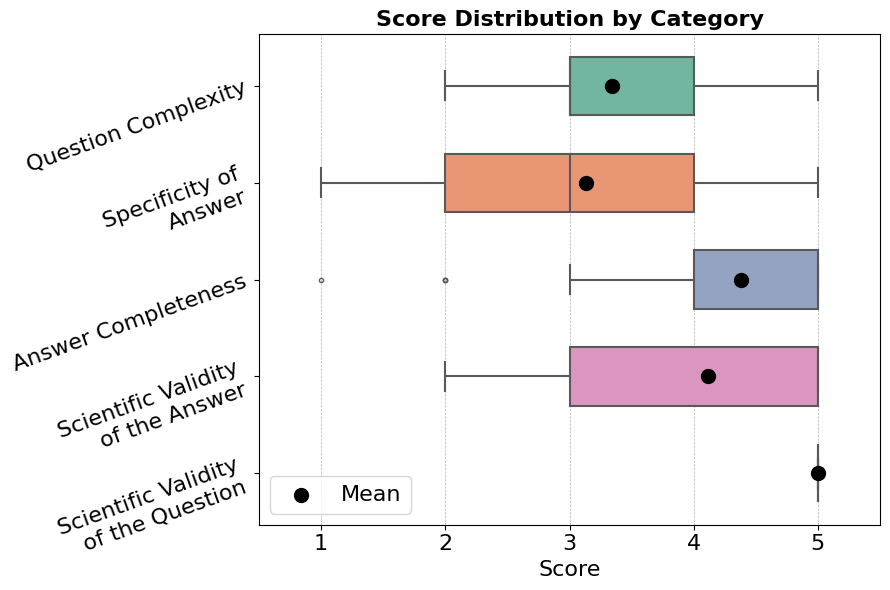

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter qualified data
qualified_df = eda_df[eda_df["Qualified"]].copy()

# Optional: Sort categories by median score
ordered_categories = (
    qualified_df.groupby("Evaluation Category")["Numeric Score"]
    .median()
    .sort_values()
    .index
)

wrapped_categories = [wrap_label(cat, max_width=19) for cat in ordered_categories]


# Create figure and boxplot
fig, ax = plt.subplots(figsize=(9, 6))  # Match figure size with first plot
sns.boxplot(
    data=qualified_df,
    x="Numeric Score",
    y="Evaluation Category",
    order=ordered_categories,
    orient='h',
    palette="Set2",  # Subtle palette
    width=0.6,
    fliersize=3,
    linewidth=1.5,
    ax=ax
)


# ax.set_yticklabels(wrapped_categories)

# Plot the mean markers
means = qualified_df.groupby("Evaluation Category")["Numeric Score"].mean()
for i, category in enumerate(ordered_categories):
    mean_value = means[category]
    ax.scatter(mean_value, i, color='black', marker='o', s=100, zorder=3, label=f"Mean" if i == 0 else "")

# Set axis labels and title with matching font sizes
ax.set_title("Score Distribution by Category", fontsize=16, fontweight='bold')
ax.set_xlabel("Score", fontsize=16)
ax.set_yticklabels(wrapped_categories)

# ax.set_ylabel("Evaluation Category", fontsize=16)
ax.set_ylabel("")


# Set axis limits
ax.set_xlim(0.5, 5.5)

# Customize tick label sizes
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)


plt.setp(ax.get_yticklabels(), rotation=20, ha='right')  # Rotate and align right for better readability



# Grid styling (matching dashed style)
ax.grid(True, axis='x', linestyle='--', linewidth=0.5)

# Add legend for mean markers with consistent font size
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower left', fontsize=16)

plt.tight_layout()
plt.savefig(PATH_TO_CONSTANTS+CONSTANTS['figures']+"Score_Distribution_category.pdf", format='pdf', dpi=300)  # Export with high resolution
plt.show()

In [6]:
# Define thresholds
thresholds = [2, 3, 4]

# Grouped result storage
results = {}

# Loop over each category
for category, group in qualified_df.groupby("Evaluation Category"):
    total = group["Numeric Score"].count()
    results[category] = {}
    for t in thresholds:
        above = (group["Numeric Score"] >= t).sum()
        percentage = (above / total) * 100 if total > 0 else 0
        results[category][f">= {t}"] = round(percentage, 2)

# Display the results
import pandas as pd
percentage_df = pd.DataFrame(results).T  # Transpose for readability
print(percentage_df)
eda_df

                                       >= 2    >= 3    >= 4
Answer Completeness                   98.11   92.45   77.36
Question Complexity                  100.00   88.68   37.74
Scientific Validity of the Answer    100.00   90.57   69.81
Scientific Validity of the Question  100.00  100.00  100.00
Specificity of Answer                 96.23   73.58   37.74


,ID,Evaluation Category,Score,Numeric Score,Qualified,Evaluation Status
0,118419,Scientific Validity of the Question,5. Completely valid: Perfectly aligned with cu...,5.0,True,Qualified
1,118419,Scientific Validity of the Answer,2. Slightly valid: Major scientific inaccuraci...,2.0,True,Qualified
2,118419,Question Complexity,5. Very complex: Question requiring synthesis ...,5.0,True,Qualified
3,118419,Specificity of Answer,2. Somewhat general: Answer provides some spec...,2.0,True,Qualified
4,118419,Answer Completeness,3. Moderately complete: Answer covers most cri...,3.0,True,Qualified
...,...,...,...,...,...,...
265,55896,Scientific Validity of the Question,5. Completely valid: Perfectly aligned with cu...,5.0,True,Qualified
266,55896,Scientific Validity of the Answer,5. Completely valid: Perfectly aligned with cu...,5.0,True,Qualified
267,55896,Question Complexity,3. Moderate: Question requiring integration of...,3.0,True,Qualified
268,55896,Specificity of Answer,5. Highly specific: Answer provides exceptiona...,5.0,True,Qualified


In [7]:
# Group by ID and Dataset Source, then compute the average score
qualified_scores = eda_df[
    (eda_df["Qualified"]) &
    (~eda_df["Evaluation Category"].isin(["Scientific Validity of the Question", "Question Complexity"]))
]


id_avg_df = (
    qualified_scores
    .groupby(["ID",])["Numeric Score"]
    .mean()
    .reset_index()
    .rename(columns={"Numeric Score": "Avg Score"})
)


id_min_df = (
    qualified_scores
    .groupby(["ID"])["Numeric Score"]
    .min()
    .reset_index()
    .rename(columns={"Numeric Score": "Min Score"})
)


In [8]:
overall_avg = id_avg_df["Avg Score"].mean()
print(f"Overall average of all average scores: {overall_avg:.2f}")

print(f"Overall minimum scores: { id_avg_df['Avg Score'].min():.2f}")

count_above_2_5 = (id_avg_df["Avg Score"] > 2.5).sum()
print(f"Number of IDs with Avg Score > 2.5: {count_above_2_5}")

percentage = (count_above_2_5 / len(id_avg_df)) * 100
print(f"Percentage: {percentage:.2f}%")

Overall average of all average scores: 3.87
Overall minimum scores: 1.67
Number of IDs with Avg Score > 2.5: 50
Percentage: 94.34%


In [9]:
overall_avg = id_min_df["Min Score"].mean()
print(f"Overall average of all minimum scores: {overall_avg:.2f}")

# print(f"Overall minimum scores: { id_avg_df['Avg Score'].min()}")

count_above_2_5 = (id_min_df["Min Score"] > 2.5).sum()
print(f"Number of IDs with Min Score > 2.5: {count_above_2_5}")

percentage = (count_above_2_5 / len(id_min_df)) * 100
print(f"Percentage: {percentage:.2f}%")

Overall average of all minimum scores: 3.02
Number of IDs with Min Score > 2.5: 38
Percentage: 71.70%


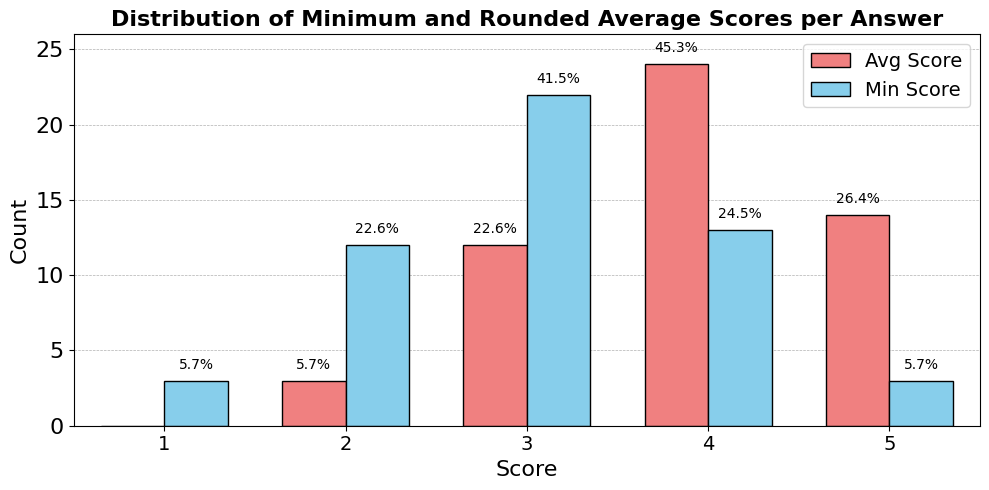

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Bin centers
bin_labels = [1, 2, 3, 4, 5]

# Count occurrences
min_counts = id_min_df["Min Score"].value_counts().reindex(bin_labels, fill_value=0).sort_index()
avg_counts = id_avg_df["Avg Score"].round().astype(int).value_counts().reindex(bin_labels, fill_value=0).sort_index()

# Totals for percentages
total_min = min_counts.sum()
total_avg = avg_counts.sum()

# Bar positions
x = np.array(bin_labels)
bar_width = 0.35

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))  # Match base style

# Plot bars with zorder to control layering
bars_avg = ax.bar(x - bar_width/2, avg_counts, width=bar_width, color='#F08080', edgecolor='black',
                  label='Avg Score', zorder=2)
bars_min = ax.bar(x + bar_width/2, min_counts, width=bar_width, color='#87CEEB', edgecolor='black',
                  label='Min Score', zorder=2)

# Annotate with percentages
for i, (bar_avg, bar_min) in enumerate(zip(bars_avg, bars_min)):
    height_avg = bar_avg.get_height()
    height_min = bar_min.get_height()
    
    if height_avg > 0:
        ax.text(bar_avg.get_x() + bar_avg.get_width()/2, height_avg + 0.8,
                f"{(height_avg/total_avg)*100:.1f}%", ha='center', fontsize=10, zorder=3)
        
    if height_min > 0:
        ax.text(bar_min.get_x() + bar_min.get_width()/2, height_min + 0.8,
                f"{(height_min/total_min)*100:.1f}%", ha='center', fontsize=10, zorder=3)

# Axis ticks and limits
ax.set_xticks(bin_labels)
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0, 26)

# Labels and title (font sizes to match)
ax.set_xlabel("Score", fontsize=16)
ax.set_ylabel("Count", fontsize=16)
ax.set_title("Distribution of Minimum and Rounded Average Scores per Answer", fontsize=16, fontweight='bold')

# Tick font sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=16)

# Legend styling
ax.legend(fontsize=14)

# Grid styling
ax.grid(True, axis='y', linestyle='--', linewidth=0.5, zorder=0)

# Tight layout
plt.tight_layout()
plt.savefig(PATH_TO_CONSTANTS+CONSTANTS['figures']+"Score_Distribution_answer.pdf", format='pdf', dpi=300)  # Export with high resolution
plt.show()


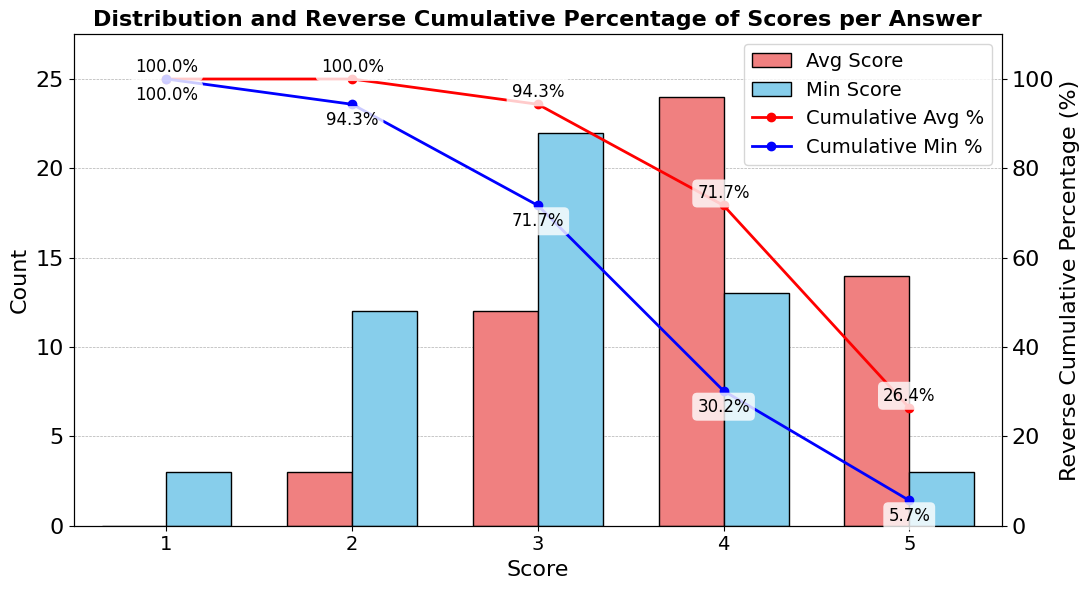

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Bin centers
bin_labels = [1, 2, 3, 4, 5]

# Count occurrences
min_counts = id_min_df["Min Score"].value_counts().reindex(bin_labels, fill_value=0).sort_index()
avg_counts = id_avg_df["Avg Score"].round().astype(int).value_counts().reindex(bin_labels, fill_value=0).sort_index()

# Totals
total_min = min_counts.sum()
total_avg = avg_counts.sum()

# Correct inverse cumulative percentages (P(score ≥ bin))
inverse_cumulative_min_pct = np.cumsum(min_counts[::-1])[::-1] / total_min * 100
inverse_cumulative_avg_pct = np.cumsum(avg_counts[::-1])[::-1] / total_avg * 100

# Bar positions
x = np.array(bin_labels)
bar_width = 0.35

# Create figure and axes
fig, ax = plt.subplots(figsize=(11, 6))  # Match base style

# Primary axis (bar chart)
bars_avg = ax.bar(x - bar_width/2, avg_counts, width=bar_width, color='#F08080', edgecolor='black',
                  label='Avg Score', zorder=2)
bars_min = ax.bar(x + bar_width/2, min_counts, width=bar_width, color='#87CEEB', edgecolor='black',
                  label='Min Score', zorder=2)

# Secondary axis (inverse cumulative percentage lines)
ax2 = ax.twinx()
ax2.plot(x, inverse_cumulative_avg_pct, color='red', marker='o', label='Cumulative Avg %', linewidth=2, zorder=3)
ax2.plot(x, inverse_cumulative_min_pct, color='blue', marker='o', label='Cumulative Min %', linewidth=2, zorder=3)

# Add value annotations to cumulative percentage lines
for i, (x_val, y_val) in enumerate(zip(x, inverse_cumulative_avg_pct)):
    ax2.annotate(f"{y_val:.1f}%", (x_val, y_val), textcoords="offset points", xytext=(0, 5),
                 ha='center', fontsize=12, color='black',
                 bbox=dict(facecolor='white', edgecolor='none',  alpha=0.8, boxstyle='round'))

for i, (x_val, y_val) in enumerate(zip(x, inverse_cumulative_min_pct)):
    ax2.annotate(f"{y_val:.1f}%", (x_val, y_val), textcoords="offset points", xytext=(0, -15),
                 ha='center', fontsize=12, color='black',
                 bbox=dict(facecolor='white', edgecolor='none',  alpha=0.8, boxstyle='round'))

# Axis ticks and limits
ax.set_xticks(bin_labels)
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0, 27.5)
ax2.set_ylim(0, 110)

# Axis labels
ax.set_xlabel("Score", fontsize=16)
ax.set_ylabel("Count", fontsize=16)
ax2.set_ylabel("Reverse Cumulative Percentage (%)", fontsize=16)

# Title
ax.set_title("Distribution and Reverse Cumulative Percentage of Scores per Answer", fontsize=16, fontweight='bold')

# Tick font sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)

# # Combine legends from both axes
# lines_labels = [*ax.get_legend_handles_labels(), *ax2.get_legend_handles_labels()]
# lines, labels = zip(*lines_labels)
# ax.legend(lines, labels, fontsize=14, loc='upper right')

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine them and assign to ax
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=14, loc='upper right')


# Grid styling

ax.grid(True, axis='y', linestyle='--', linewidth=0.5, zorder=0)

# Tight layout
plt.tight_layout()
plt.savefig(PATH_TO_CONSTANTS+CONSTANTS['figures']+"Score_Distribution_answer.pdf", format='pdf', dpi=300)
plt.show()
